# Part A: Conceptual Understanding (Theory)

## 1. What are Supervised Learning Algorithms?

Supervised Learning Algorithms are machine learning algorithms that learn from labeled data. They use input features and corresponding target values to make predictions on unseen data. Examples include Linear Regression, Logistic Regression, Decision Trees, and Support Vector Machines.

---

## 2. Difference between Regression Algorithms vs Classification Algorithms

| Regression Algorithms | Classification Algorithms |
|----------------------|--------------------------|
| Predict continuous numerical values. | Predict categorical labels or classes. |
| Output is a numeric value. | Output is a category or class. |
| Used for forecasting and estimation. | Used for grouping and categorization. |
| Example: House Price Prediction. | Example: Spam Email Detection. |

---

## 3. Explain Simple Linear Regression.

Simple Linear Regression is a supervised learning algorithm used to model the relationship between one independent variable and one dependent variable. It fits a straight line through the data using the equation:

**Y = mX + c**

where **m** is the slope and **c** is the intercept. It is commonly used for prediction and trend analysis.

---

## 4. List and Explain the Assumptions of Linear Regression.

1. **Linearity:** The relationship between independent and dependent variables should be linear.
2. **Independence:** Observations should be independent of each other.
3. **Homoscedasticity:** The variance of residuals should remain constant.
4. **Normality of Residuals:** Residual errors should be approximately normally distributed.
5. **No Multicollinearity:** Independent variables should not be highly correlated with one another.

---

## 5. What is Bias–Variance Trade-Off?

The Bias–Variance Trade-Off is the balance between underfitting and overfitting in machine learning. High bias causes underfitting because the model is too simple, while high variance causes overfitting because the model learns noise from training data. The goal is to achieve an optimal balance for good generalization.

---

## 6. Explain Overfitting and Underfitting with Examples.

### Overfitting
Overfitting occurs when a model learns the training data too closely, including noise and outliers, resulting in poor performance on unseen data. For example, a high-degree polynomial regression model may perfectly fit the training data but perform poorly on test data.

### Underfitting
Underfitting occurs when a model is too simple to capture the underlying patterns in the data. For example, using a simple linear model to represent a highly complex non-linear relationship may result in poor performance on both training and testing data.

### Example
In house price prediction, a simple straight-line model may underfit the data, while a very complex polynomial model may overfit it. A well-balanced model provides the best prediction performance.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [3]:
df = pd.read_csv("/content/RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv.csv")

df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [4]:
X = df.drop(
    columns=["house_price_inr", "house_id"]
)

y = df["house_price_inr"]

print("Independent Variables:")
print(X.columns)

print("\nDependent Variable:")
print(y.name)

Independent Variables:
Index(['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years',
       'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool',
       'renovation_years_ago'],
      dtype='object')

Dependent Variable:
house_price_inr


In [5]:
print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB
None
            house_id    area_sqft     bedrooms    bathrooms  location_score  \
count    4200.000000  4200.000000  4200.00

In [6]:
print(df.isnull().sum())

house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64


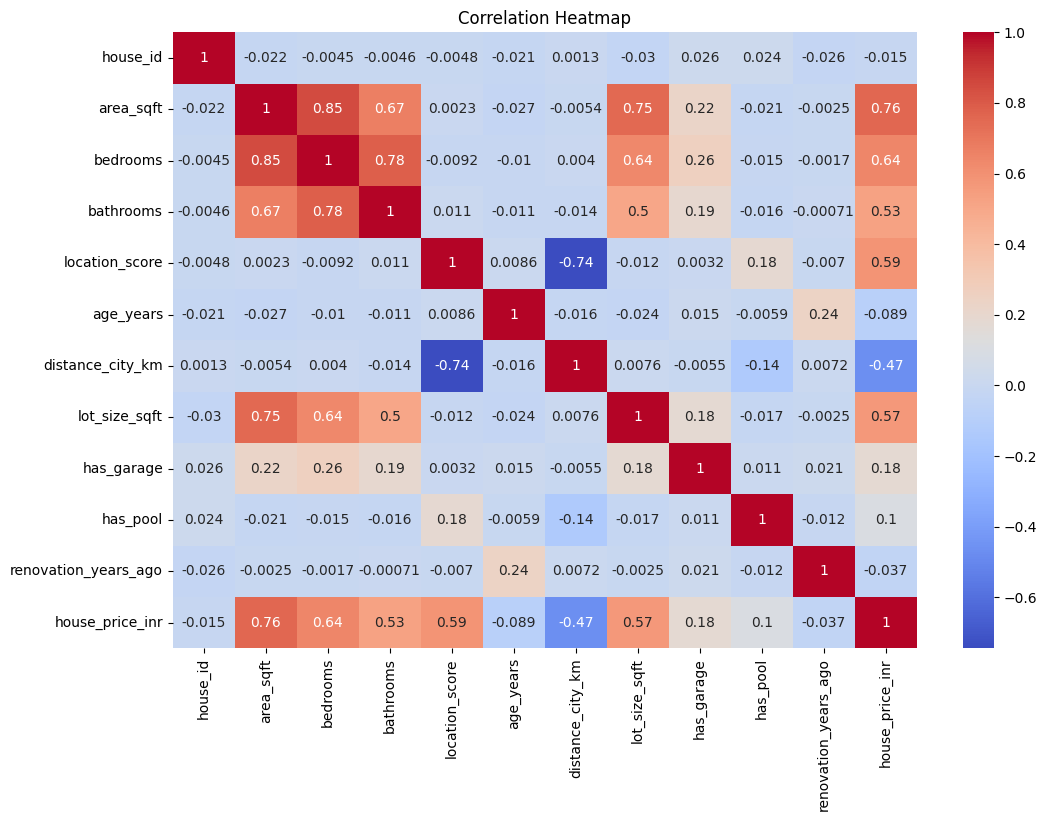

In [7]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

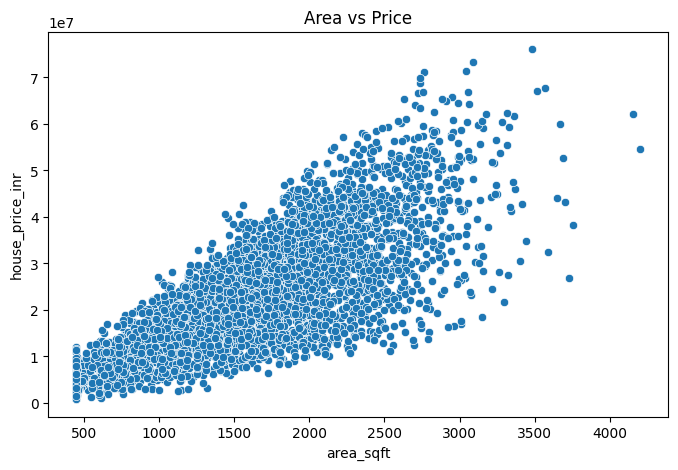

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["area_sqft"],
    y=df["house_price_inr"]
)

plt.title("Area vs Price")
plt.show()

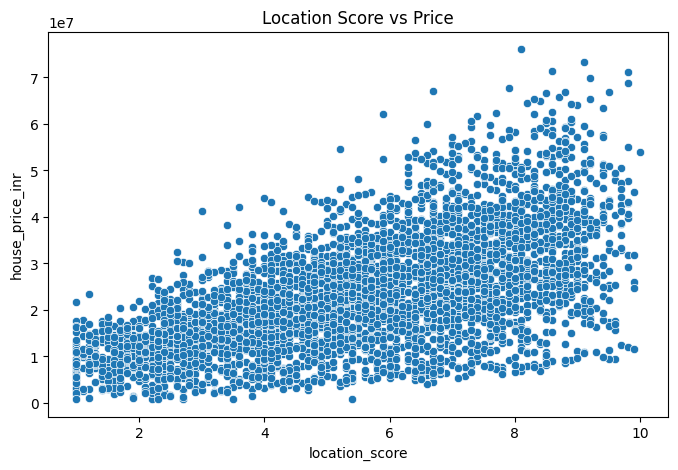

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["location_score"],
    y=df["house_price_inr"]
)

plt.title("Location Score vs Price")
plt.show()

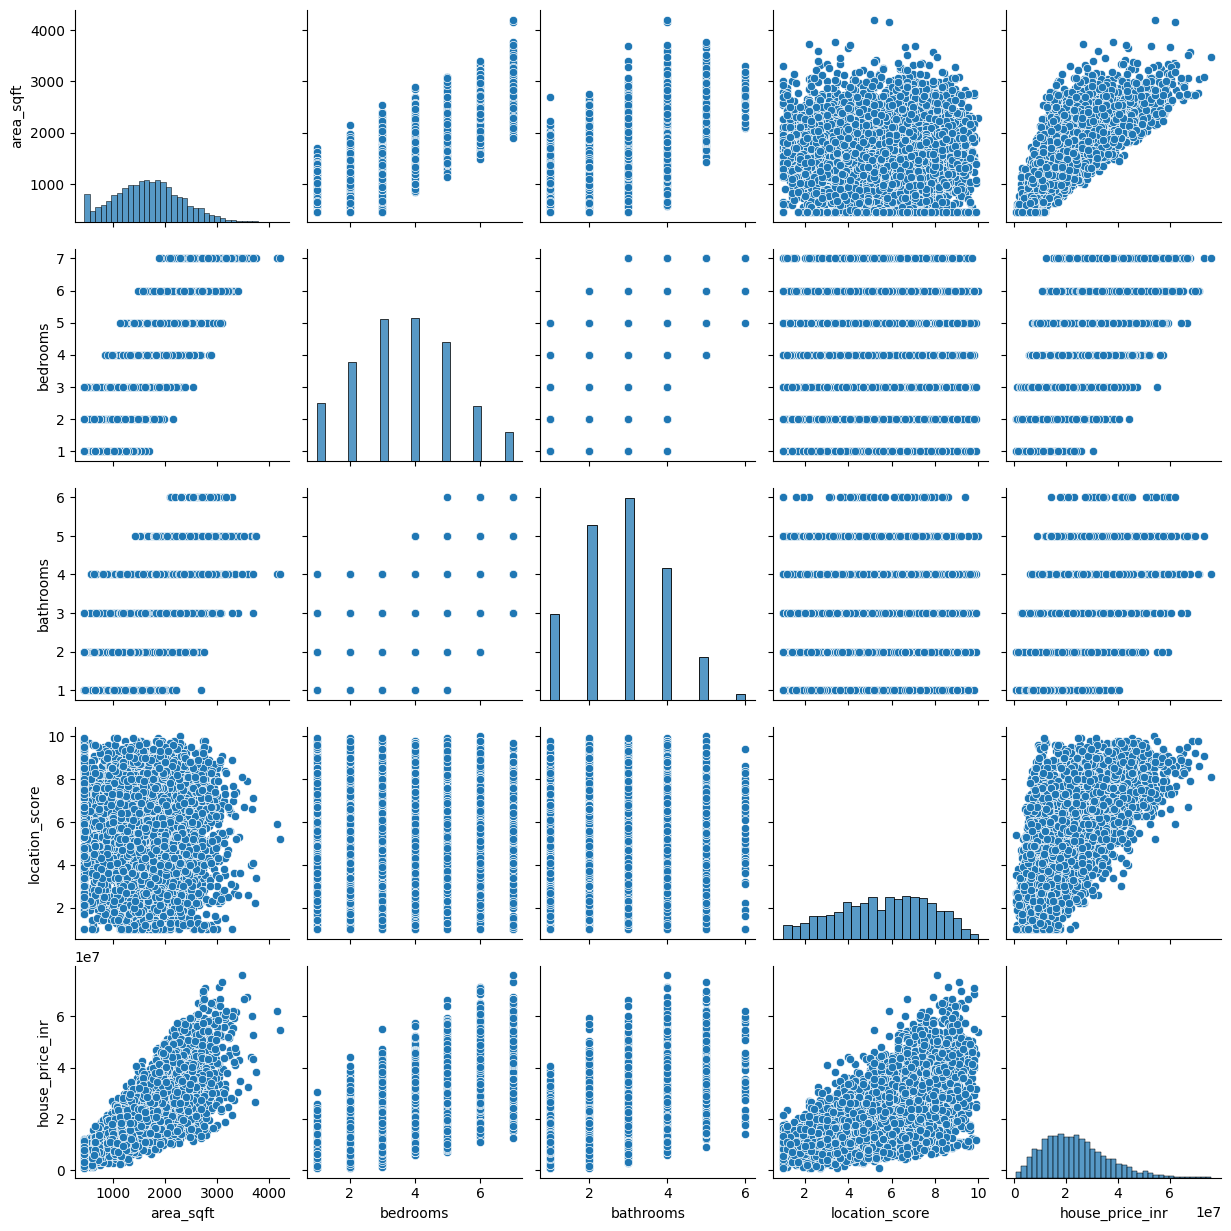

In [10]:
sns.pairplot(
    df[
        [
            "area_sqft",
            "bedrooms",
            "bathrooms",
            "location_score",
            "house_price_inr"
        ]
    ]
)

plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3360, 10)
(840, 10)


In [12]:
X_simple = df[["area_sqft"]]

y = df["house_price_inr"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(
    X_train_s,
    y_train_s
)

y_pred_simple = simple_model.predict(X_test_s)

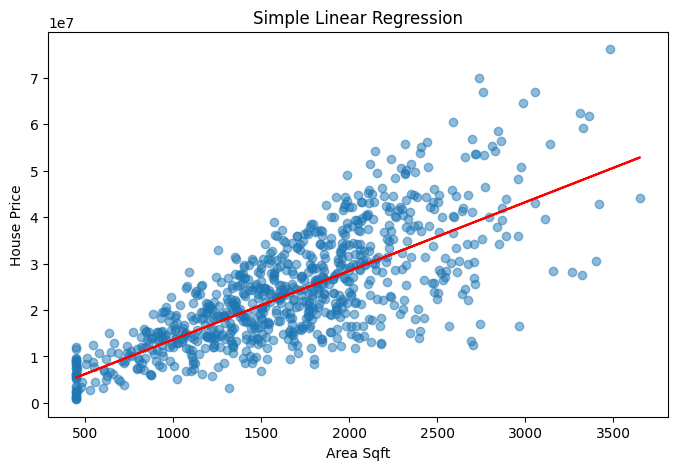

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_test_s,
    y_test_s,
    alpha=0.5
)

plt.plot(
    X_test_s,
    y_pred_simple,
    color="red"
)

plt.xlabel("Area Sqft")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")

plt.show()

In [14]:
print("Slope:")
print(simple_model.coef_[0])

print("\nIntercept:")
print(simple_model.intercept_)

Slope:
14788.306111307542

Intercept:
-1163519.1764186136


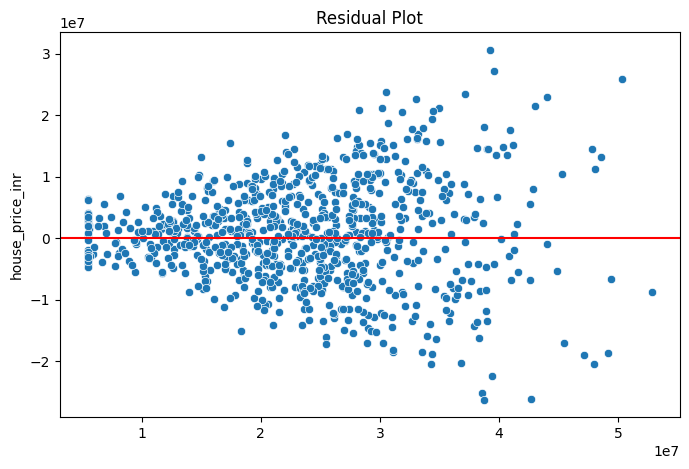

In [15]:
residuals = y_test_s - y_pred_simple

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_pred_simple,
    y=residuals
)

plt.axhline(
    y=0,
    color='red'
)

plt.title("Residual Plot")
plt.show()

In [16]:
mse = mean_squared_error(
    y_test_s,
    y_pred_simple
)

mae = mean_absolute_error(
    y_test_s,
    y_pred_simple
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_s,
    y_pred_simple
)

n = len(y_test_s)
p = 1

adj_r2 = 1 - (
    (1-r2)*(n-1)/(n-p-1)
)

print("MSE :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print("R2 :", r2)
print("Adjusted R2 :", adj_r2)

MSE : 66989260021849.47
MAE : 6294593.696131912
RMSE : 8184696.696997969
R2 : 0.5625199587991578
Adjusted R2 : 0.5619979062440257


In [17]:
multi_model = LinearRegression()

multi_model.fit(
    X_train,
    y_train
)

y_pred_multi = multi_model.predict(
    X_test
)

In [18]:
mse_multi = mean_squared_error(
    y_test,
    y_pred_multi
)

mae_multi = mean_absolute_error(
    y_test,
    y_pred_multi
)

rmse_multi = np.sqrt(
    mse_multi
)

r2_multi = r2_score(
    y_test,
    y_pred_multi
)

n = len(y_test)
p = X.shape[1]

adj_r2_multi = 1 - (
    (1-r2_multi)*(n-1)/(n-p-1)
)

print("MSE :", mse_multi)
print("MAE :", mae_multi)
print("RMSE :", rmse_multi)
print("R2 :", r2_multi)
print("Adjusted R2 :", adj_r2_multi)

MSE : 12592918884127.615
MAE : 2604991.4061556906
RMSE : 3548650.290480539
R2 : 0.9177606877509898
Adjusted R2 : 0.916768657446418


In [19]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly = poly.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42
)

poly_model = LinearRegression()

poly_model.fit(
    X_train_p,
    y_train_p
)

y_pred_poly = poly_model.predict(
    X_test_p
)

In [20]:
mse_poly = mean_squared_error(
    y_test_p,
    y_pred_poly
)

mae_poly = mean_absolute_error(
    y_test_p,
    y_pred_poly
)

rmse_poly = np.sqrt(
    mse_poly
)

r2_poly = r2_score(
    y_test_p,
    y_pred_poly
)

print("MSE :", mse_poly)
print("MAE :", mae_poly)
print("RMSE :", rmse_poly)
print("R2 :", r2_poly)

MSE : 5139490891528.84
MAE : 1656922.8020194264
RMSE : 2267044.5279104775
R2 : 0.9664360423410553


In [21]:
results = pd.DataFrame({

    "Model":[
        "Simple LR",
        "Multiple LR",
        "Polynomial"
    ],

    "R2":[
        r2,
        r2_multi,
        r2_poly
    ],

    "RMSE":[
        rmse,
        rmse_multi,
        rmse_poly
    ]
})

print(results)

         Model        R2          RMSE
0    Simple LR  0.562520  8.184697e+06
1  Multiple LR  0.917761  3.548650e+06
2   Polynomial  0.966436  2.267045e+06


In [22]:
X_gd = df[["area_sqft"]].values
y_gd = df["house_price_inr"].values

m = len(X_gd)

w = 0
b = 0

lr = 0.00000001

epochs = 1000

for i in range(epochs):

    y_pred = w*X_gd.flatten() + b

    dw = (-2/m) * np.sum(
        X_gd.flatten() *
        (y_gd - y_pred)
    )

    db = (-2/m) * np.sum(
        y_gd - y_pred
    )

    w -= lr*dw
    b -= lr*db

print("Weight:",w)
print("Bias:",b)

Weight: 14263.395276489347
Bias: 4.679087504821976


In [23]:
print(
    "Simple LR Train:",
    simple_model.score(
        X_train_s,
        y_train_s
    )
)

print(
    "Multiple LR Train:",
    multi_model.score(
        X_train,
        y_train
    )
)

print(
    "Polynomial Train:",
    poly_model.score(
        X_train_p,
        y_train_p
    )
)

Simple LR Train: 0.5723074839148459
Multiple LR Train: 0.9247216651865339
Polynomial Train: 0.9684556843111441


In [24]:
print(
    "Simple LR Test:",
    simple_model.score(
        X_test_s,
        y_test_s
    )
)

print(
    "Multiple LR Test:",
    multi_model.score(
        X_test,
        y_test
    )
)

print(
    "Polynomial Test:",
    poly_model.score(
        X_test_p,
        y_test_p
    )
)

Simple LR Test: 0.5625199587991578
Multiple LR Test: 0.9177606877509898
Polynomial Test: 0.9664360423410553


## **PART-I**
1. Multiple Linear Regression performed better than Simple Linear Regression because it used all property features.

2. Polynomial Regression captured non-linear relationships and achieved the highest R² score.

3. Gradient Descent successfully optimized model parameters.

4. If Polynomial Regression shows very high training score but lower test score, it indicates overfitting.

5. Based on evaluation metrics, the model with highest R² and lowest RMSE is considered the best model for house price prediction.